In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

def read_coordinates(file_path,bbox):
    frames = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 1:
                bbox = line[line.find("(")+1:line.find(")")]
                bbox = tuple(map(int, bbox.split(', ')))
            if len(parts) == 5:
                frame_id = int(parts[0])
                x = float(parts[2])-bbox[2]
                y = float(parts[3])-bbox[0]
                
                if frame_id not in frames:
                    frames[frame_id] = []
                frames[frame_id].append((x, y))
    return frames

def load_images_from_directory(directory):
    files = sorted([os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(('png', 'jpg', 'jpeg'))])
    print("loading images...")
    images = [cv2.imread(file) for file in tqdm(files)]
    return images

def show_image_and_coordinates(frame_num, coords, images, bbox):
    image = images[frame_num]

    image = image[bbox[0]:bbox[1],bbox[2]:bbox[3]]
    result = image.copy()
    for coord in coords[frame_num]:
        result[int(coord[1]),int(coord[0])] = [255,0,0]
    plt.imshow(result)
    plt.show()

    return image, coords


loading images...


100%|██████████| 1500/1500 [00:06<00:00, 224.31it/s]


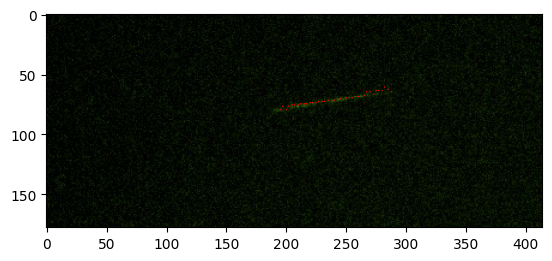

(668, 1200, 3)


In [4]:


file_path = '/home/yuming/Documents/dev/python/projects/microtubule-tracking-2/rough_coordinates.txt'
images_path = '/home/yuming/Documents/mt_data/MT10_30min_200x_1500_138_146pm'
bbox = (81, 259, 103, 517)
coords = read_coordinates(file_path,bbox)
images = load_images_from_directory(images_path)



img, crds = show_image_and_coordinates(1400,coords,images,bbox)
print(images[1400].shape)

In [43]:
print(np.array(data_track[0]).shape)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.

In [38]:
new_points, variances = fitted_points(data, data_coords)
new_points = refit_spline(new_points)
plot_spline(new_points, None, image)

plt.imshow(data[:,1,:])
vars = np.var(data[:,1,:],axis=1)
plt.show()
plt.scatter(np.linspace(0,1,num=len(vars)),vars)

NameError: name 'data_coords' is not defined

In [ ]:
dontshoot = 0
from tsp_solver.greedy import solve_tsp
from scipy.interpolate import splprep, splev
from scipy.ndimage import map_coordinates
from scipy.optimize import curve_fit
from concurrent.futures import ProcessPoolExecutor, as_completed
import cv2

def spline_and_normals(coords, image, bbox, eps = 0):
    image = image[bbox[0]:bbox[1],bbox[2]:bbox[3],:]
    dist = lambda p1, p2: np.sqrt(((p1-p2)**2).sum())
    dist_matrix = np.asarray([[dist(p1, p2) for p2 in coords] for p1 in coords])
    path = solve_tsp(dist_matrix.tolist())
    ordered_points = coords[path]
    tck, u = splprep([ordered_points[:, 0], ordered_points[:, 1]], s = coords.shape[0])
    t_vals = np.linspace(0, 1, 100)
    spline = splev(t_vals, tck)

    dx_start, dy_start = splev(0, tck, der=1)  # Start point derivative
    dx_end, dy_end = splev(1, tck, der=1)      # End point derivative
    u_start = np.linspace(-eps, 0, int(eps*100))
    u_end = np.linspace(1, 1+eps, int(eps*100))
    linear_x_start = spline[0][0] + dx_start * u_start
    linear_y_start = spline[1][0] + dy_start * u_start
    linear_x_end = spline[0][-1] + dx_end * (u_end - 1)
    linear_y_end = spline[1][-1] + dy_end * (u_end - 1)
    x_full = np.concatenate([linear_x_start, spline[0], linear_x_end])
    y_full = np.concatenate([linear_y_start, spline[1], linear_y_end])
    spline = [x_full, y_full]

    derivatives = splev(np.linspace(-eps, 1+eps, int(100*(1+2*eps))), tck, der=1)
    tangent_norm = np.sqrt(derivatives[0]**2 + derivatives[1]**2)
    normal_x = derivatives[0] / tangent_norm
    normal_y = -derivatives[1] / tangent_norm
    points = np.array(list(zip(spline[0],spline[1])))

    return points, [normal_x, normal_y], image

def plot_spline(points, vectors, image, arrow_scaling_factor = 5, show_arrows = False):

    plt.imshow(image)

    for i, point in enumerate(points):
        if i % 2 == 0:
            plt.plot(point[1], point[0], 'ro', ms=1)  # Plot point (x, y) on the image
            if vectors is not None:
                plt.arrow(point[1], point[0], vectors[0][i]*arrow_scaling_factor, vectors[1][i]*arrow_scaling_factor, color='yellow', head_width=1)
    plt.rcParams["figure.figsize"] = (10,10)
    plt.title('Spline with normal vectors')
    plt.axis('off')
    plt.show()

def get_gaussian_data(points, vectors, image):
    line_length = 10
    num_points_along_line = 50

    vectors = np.vstack((vectors[0],vectors[1])).T*5  
    vector_lengths = np.linalg.norm(vectors, axis=1)
    unit_vectors = vectors / vector_lengths[:, None]  
    interpolated_data = []
    interpolated_data_coordinates = []

    for i, point in enumerate(points):
        unit_vector = unit_vectors[i]

        t_values = np.linspace(-line_length, line_length, num=num_points_along_line) 
        line_points = point[:, None] + t_values * unit_vector[:, None] 
        y_coords, x_coords = line_points[0], line_points[1]

        line_data_channels = []
        for channel in range(image.shape[2]):
            line_data = map_coordinates(image[:, :, channel], [y_coords, x_coords], order=3)
            line_data_channels.append(line_data)

        line_data_combined = np.vstack(line_data_channels).T
        interpolated_data.append(np.array(line_data_combined).T)
        interpolated_data_coordinates.append(np.array([y_coords,x_coords]))

    interpolated_data = np.array(interpolated_data)  
    interpolated_data_coordinates = np.array(interpolated_data_coordinates)
    return interpolated_data, interpolated_data_coordinates

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

def gaussian_fit(x):
    x_vals = np.arange(len(x))
    initial_guess = [max(x), np.argmax(x), 1.0]
    params, _ = curve_fit(gaussian, x_vals, x, p0=initial_guess)
    if dontshoot < 10:
        print(x)
        dontshoot = dontshoot+1
    return params[1]

def fitted_points(data, data_coords):
    points = np.zeros(shape=(data.shape[0],2))
    variances = np.zeros(shape=(data.shape[0],3))
    for i, d in enumerate(data):
        max = np.argmax(d,axis=1)
        variances[i] = np.var(d,axis=1)
        points[i] = np.average(data_coords[i,:,max],axis=0)

    return points, variances
        
def refit_spline(coords):

    dist = lambda p1, p2: np.sqrt(((p1-p2)**2).sum())
    dist_matrix = np.asarray([[dist(p1, p2) for p2 in coords] for p1 in coords])
    path = solve_tsp(dist_matrix.tolist())
    ordered_points = coords[path]
    tck, u = splprep([ordered_points[:, 0], ordered_points[:, 1]], s = coords.shape[0])
    t_vals = np.linspace(0,1,100)
    spline = splev(t_vals, tck)

    return np.array(spline).T

def process_image_a(i, image, coords, bbox):
    points, vectors, image = spline_and_normals(coords=np.array(coords[i]), image=image, bbox=bbox)
    data, data_coords = get_gaussian_data(points, vectors, image)
    return [points, vectors, image, data, data_coords]
    
def track(coords, images, bbox, range = None):
    data_track = []
    if range is not None:
        images = images[range[0]:range[1]]

    with ProcessPoolExecutor() as executor:
        futures = {executor.submit(process_image_a, i, image, coords, bbox): i for i, image in enumerate(images)}

    # Collect results in the order of images by using the saved index
    for future in tqdm(as_completed(futures), total=len(images)):
        index = futures[future]
        data_track.append((index, future.result()))

    # Sort data_track by the original index
    data_track.sort(key=lambda x: x[0])
    data_track = [result for _, result in data_track]  # Extract sorted results

    return data_track



In [85]:

import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt

def trans(M):
    return [[M[j][i] for j in range(len(M))] for i in range(len(M[0]))]

def get_rpt_points(array):
    points = []
    for i in tqdm(range(array.shape[0])):
        x = array[i]
        t = np.linspace(-1,1,num=x.shape[0]) 
        algo = rpt.Pelt(model="rbf").fit(x)
        pts = algo.predict(pen=20)
        for p in pts:
            points.append([i,p])
    return np.array(points).T




data_track = track(coords, images, bbox)


100%|██████████| 1500/1500 [00:00<00:00, 758372.23it/s]


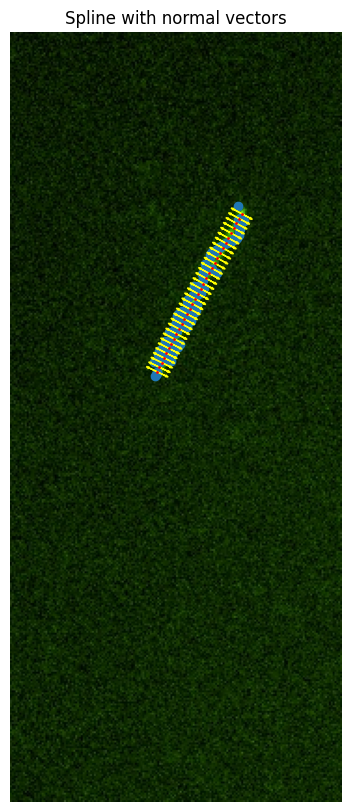

In [82]:
num = 1

def plot_spline(points, vectors, image, arrow_scaling_factor = 5, show_arrows = False):

    plt.imshow(image)
    plt.scatter(pts[:,1],pts[:,0])
    for i, point in enumerate(points):
        if i % 3 == 0 and i > len(points)-100:
            plt.plot(point[1], point[0], 'ro', ms=1)  # Plot point (x, y) on the image
            if vectors is not None:
                plt.arrow(point[1], point[0], vectors[0][i]*arrow_scaling_factor, vectors[1][i]*arrow_scaling_factor, color='yellow', head_width=1)
                plt.arrow(point[1], point[0], -1*vectors[0][i]*arrow_scaling_factor, -1*vectors[1][i]*arrow_scaling_factor, color='yellow', head_width=1)
    plt.rcParams["figure.figsize"] = (10,10)
    plt.title('Spline with normal vectors')
    plt.axis('off')
    plt.show()
plt.figure(figsize=(10,10))
plot_spline(data_track[num][0],data_track[num][1],np.swapaxes(data_track[num][2],0,1))


(100, 3, 120)
59.0


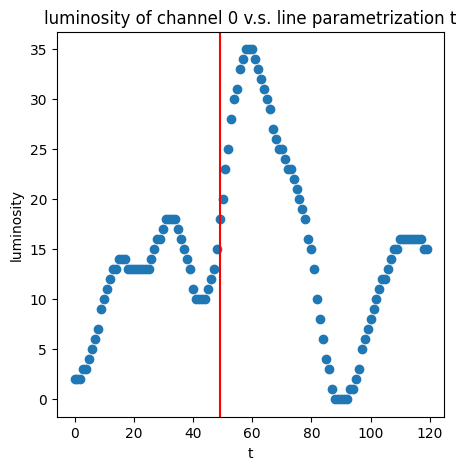

In [71]:

print(data_track[num][3].shape)
q = data_track[num][3][50,0,:]
print(np.median(np.argwhere(q == np.max(q))))
plt.figure(figsize=(5,5))
plt.axvline(49,color='red')
plt.xlabel('t')
plt.ylabel('luminosity')
plt.title('luminosity of channel 0 v.s. line parametrization t')
plt.scatter(range(len(q)),q)

In [86]:
final_coordinates_file = '/home/yuming/Documents/dev/python/projects/microtubule-tracking-2/final_coordinates.txt'
file = open(final_coordinates_file, 'a')

for i in tqdm(range(len(data_track))):
    coords4 = data_track[i][0]
    for j in range(coords4.shape[0]):
        file.write(f"{i}\t{j}\t{coords4[j,0]+bbox[2]}\t{coords4[j,1]+bbox[0]}\t0\n")

100%|██████████| 1500/1500 [00:00<00:00, 8978.98it/s]


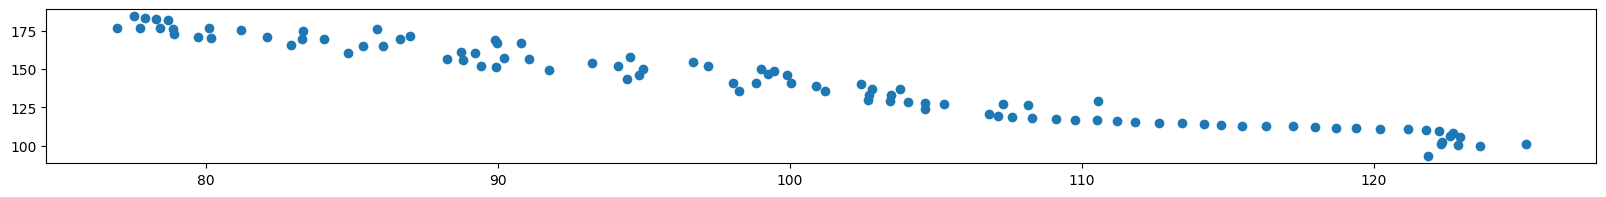

In [ ]:
pts = np.zeros((data_track[num][3].shape[0],2))

for i in range(data_track[num][3].shape[0]):
    q = data_track[num][3][i,0,:]
    
    pts[i] = data_track[num][4][i,:,int(np.median(np.argwhere(q == np.max(q))))]
